# Superstore Sales & Profit Analysis

## Objective
Analyze a retail superstore dataset to identify sales trends, profitability drivers, and the impact of discounting on business performance.

## Dataset
This dataset contains transactional data including orders, sales, profit, discounts, customer segments, and product categories.product categories from a retail superstore.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv("SuperStore_Orders.csv", encoding='latin1')

df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [10]:
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [29]:
df['order_date'] = pd.to_datetime(df['order_date'], format="%d-%m-%Y")
df['ship_date'] = pd.to_datetime(df['ship_date'], format="%d-%m-%Y")
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [30]:
df = df[df['sales'] != 0]
df = df.drop_duplicates()
df = df.dropna(subset=['sales', 'profit'])

## Data Cleaning
- Standardized all column names to lowercase
- Converted `order_date` and `ship_date` to datetime format
- Converted `sales` to numeric, coercing invalid entries
- Removed records where sales = 0
- Removed duplicate rows
- Dropped rows with null values in `sales` or `profit`


In [31]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011


In [4]:
df.shape

(51290, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [6]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [7]:
df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [11]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce').fillna(0)
sales_category = df.groupby('category')['sales'].sum().sort_values(ascending=False)
sales_category

,sales
category,
Office Supplies,2790258.0
Technology,2638265.0
Furniture,2406605.0


In [12]:
(df.groupby('category')['sales'].sum() / df['sales'].sum()) * 100

,sales
category,
Furniture,30.715580
Office Supplies,35.612156
Technology,33.672264


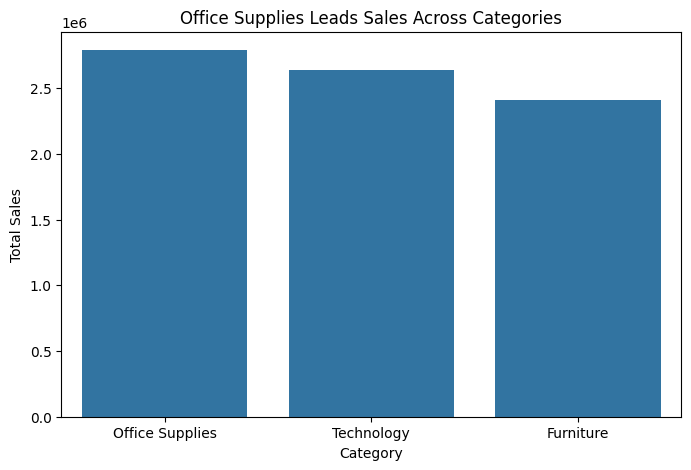

In [49]:
plt.figure(figsize=(8, 5))
sns.barplot(x=sales_category.index, y=sales_category.values)
plt.title("Office Supplies Leads Sales Across Categories")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

###Insight

Office Supplies generates the highest total sales among all categories, slightly outperforming Technology. This indicates strong and consistent demand across a wide range of essential products.

In [14]:
profit_category = df.groupby('category')['profit'].sum().sort_values(ascending=False)
profit_category

,profit
category,
Technology,663778.73318
Office Supplies,518473.83430
Furniture,286782.25380


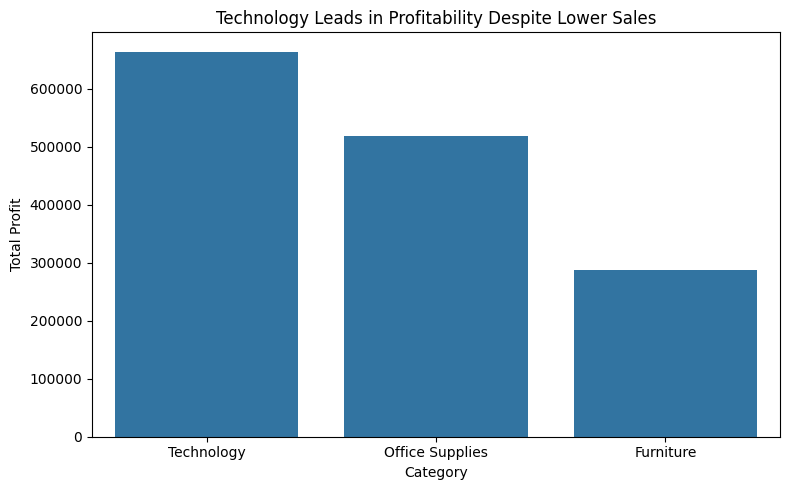

In [48]:
plt.figure(figsize=(8, 5))
sns.barplot(x=profit_category.index, y=profit_category.values)
plt.title("Technology Leads in Profitability Despite Lower Sales")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()

### Insight
Although Office Supplies generates the highest sales, it does not correspondingly produce the highest profit, suggesting lower margins and potential inefficiencies in pricing or cost structure.

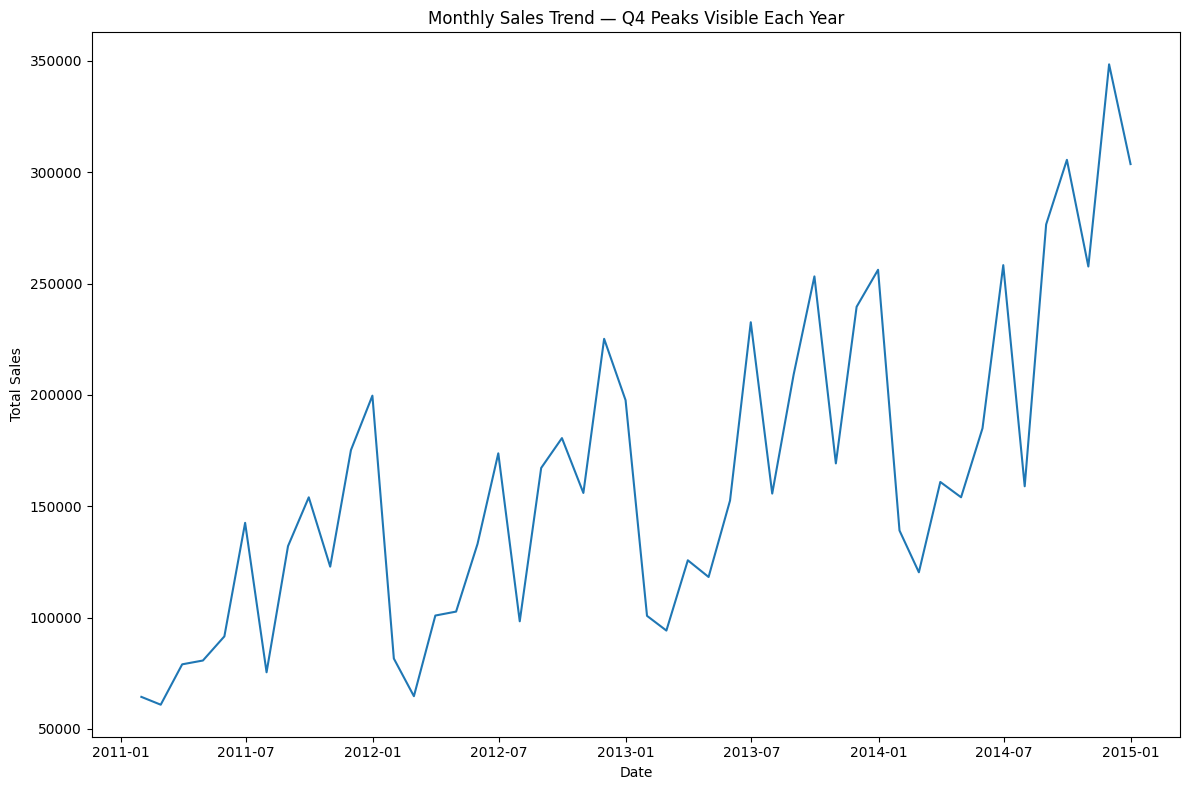

In [44]:
df['order_date'] = pd.to_datetime(df['order_date'], format="%Y-%m-%d", errors='coerce')
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

monthly_sales = df.resample('ME', on='order_date')['sales'].sum()

plt.figure(figsize=(12, 8))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title("Monthly Sales Trend — Q4 Peaks Visible Each Year")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

### Insight
Sales trends show a clear upward trajectory over time, indicating consistent business growth across the observed period.

In addition, there are strong and recurring spikes in the final months of each year (Q4), suggesting seasonal demand patterns likely driven by year-end purchasing behavior.

However, significant fluctuations between peak periods indicate demand volatility, highlighting the need for better demand forecasting and inventory planning.

This pattern suggests that while the business is growing, it relies heavily on seasonal peaks, making it important to optimize operations during high-demand periods and stabilize performance during off-peak months.

In [17]:
top_customers = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)
top_customers

,sales
customer_name,
Eric Murdock,19489.0
John Grady,19483.0
Maria Etezadi,18237.0
Theone Pippenger,17416.0
Dan Reichenbach,16705.0
Ben Ferrer,16661.0
Randy Bradley,16399.0
Mathew Reese,16125.0
Muhammed Yedwab,16091.0


In [18]:
top10 = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10).sum()
total = df['sales'].sum()

(top10 / total) * 100

np.float64(2.202771926636042)

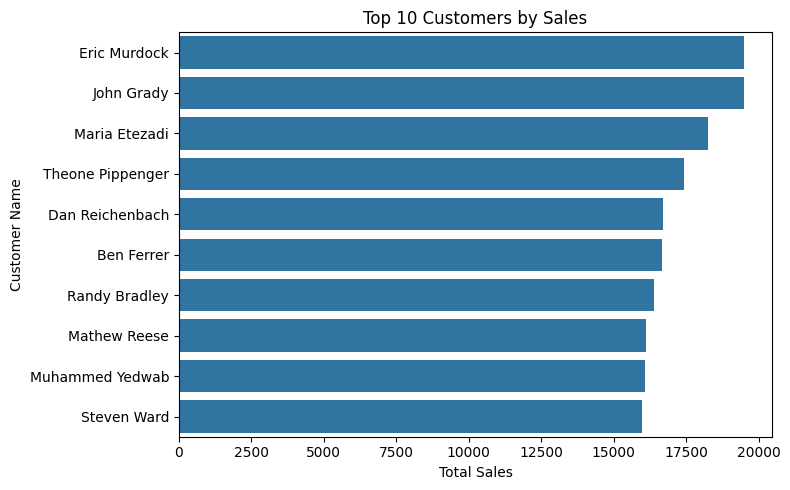

In [55]:
plt.figure(figsize=(8, 5))
sns.barplot(x=top_customers.values, y=top_customers.index, orient='h')
plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")
plt.tight_layout()
plt.show()

### Insight
The top 10 customers contribute only approximately 2.2% of total sales, indicating that revenue is widely distributed across a large customer base rather than concentrated among a few key clients.

In [20]:
df[['discount', 'profit']].corr()

,discount,profit
discount,1.000000,-0.316375
profit,-0.316375,1.000000


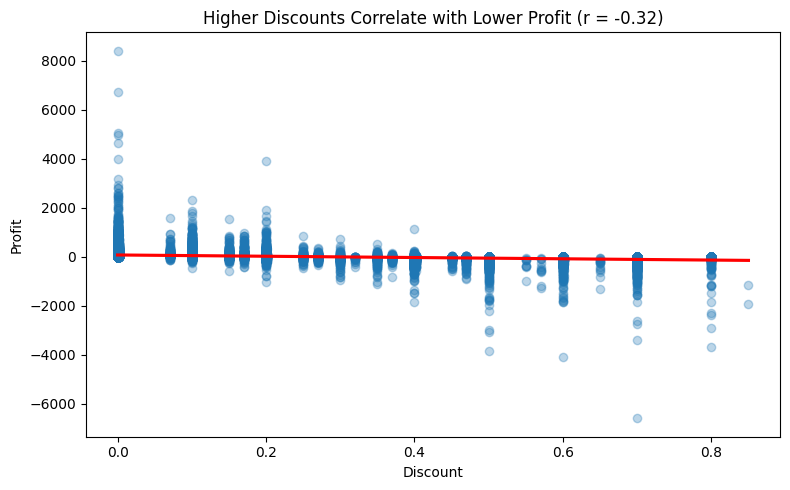

In [58]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='discount', y='profit',
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title("Higher Discounts Correlate with Lower Profit (r = -0.32)")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

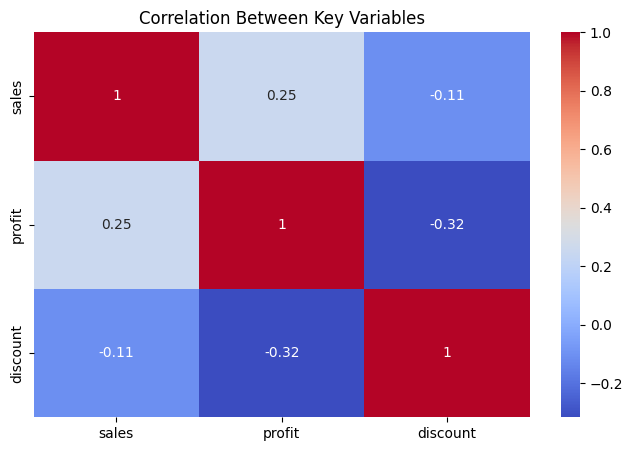

In [68]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[['sales','profit','discount']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Key Variables")
plt.show()

### Heatmap Insights

The correlation heatmap reveals important relationships between sales, profit, and discount.

- There is a moderate negative correlation (-0.32) between discount and profit, confirming that higher discount levels consistently reduce profitability.

- The correlation between sales and profit is extremely weak (0.059), indicating that higher sales do not necessarily translate into higher profit due to varying margins and cost structures.

- The relationship between discount and sales is also weak (-0.093), suggesting that increasing discounts does not significantly drive higher sales.

Overall, the analysis indicates that discounting reduces profitability without meaningfully increasing sales, highlighting an inefficient pricing strategy.

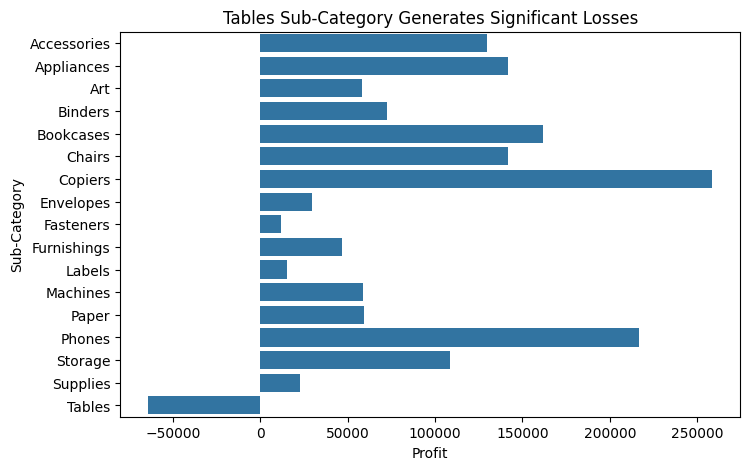

In [67]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=df.groupby('sub_category')['profit'].sum().values,
    y=df.groupby('sub_category')['profit'].sum().index
)
plt.title("Tables Sub-Category Generates Significant Losses")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")
plt.show()

## Critical Finding

The Tables sub-category is generating significant losses (~ -50K), making it the largest contributor to overall profitability decline.

Further analysis suggests that this may be driven by excessive discounting and poor margin structure, indicating a critical need for pricing and cost optimization in this segment.

In [61]:
df['profit_margin'] = df['profit'] / df['sales']

In [72]:
# Business-level (weighted) profit margin by category
margin_category = (
    df.groupby('category')['profit'].sum()
    / df.groupby('category')['sales'].sum()
).sort_values()

margin_category

(margin_category * 100).round(2)

,0
category,
Furniture,11.92
Office Supplies,18.58
Technology,25.16


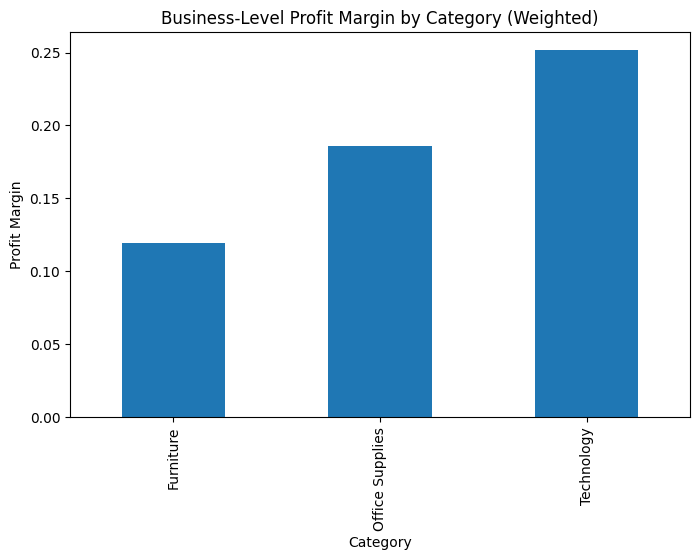

In [73]:
plt.figure(figsize=(8, 5))

margin_category.plot(kind='bar')
plt.title("Business-Level Profit Margin by Category (Weighted)")
plt.xlabel("Category")
plt.ylabel("Profit Margin")
plt.show()

###Insight

### Insight

At the business level, Technology demonstrates the highest profit margin ~25%, followed by Office Supplies ~18%, while Furniture remains the least efficient ~12%.

However, deeper analysis reveals that despite an overall positive margin, the Furniture category contains significant internal inefficiencies—particularly the Tables sub-category, which generates substantial losses (~ -50K). This indicates that profitability within Furniture is uneven and partially offset by stronger-performing sub-categories.

This suggests that while Furniture appears viable at an aggregate level, it contains structurally unprofitable segments that require targeted intervention rather than category-wide conclusions.

## Key Insights

* Office Supplies generates the highest total sales, slightly outperforming Technology, making it the primary revenue driver.

* Profitability varies significantly across categories; Technology ~25.2% has the highest margin, Office Supplies ~18.6% follows, while Furniture ~11.9% has the lowest margin, indicating structural inefficiencies.

* Sales trends show consistent growth over time with strong seasonal spikes in the final months (Q4), along with noticeable volatility between peak periods.

* Revenue is widely distributed across customers, with the top 10 customers contributing only ~2.2% of total sales, indicating low customer concentration.

* There is a moderate negative correlation (-0.32) between discount and profit, confirming that higher discount levels reduce profitability.

* The relationship between discount and sales is very weak (-0.093), indicating that discounting does not significantly increase sales.

* The correlation between sales and profit is also weak (0.059), showing that higher sales do not necessarily translate into higher profitability.

* Sub-category performance is highly uneven; while Copiers and Phones generate strong profits, the Tables sub-category incurs significant losses (~ -50K), making it the most unprofitable segment.

* Category-level profitability can mask sub-category level losses, as seen in Furniture. This highlights the importance of granular analysis when making business decisions.

## Recommendations

* Reduce excessive discounting, as it significantly lowers profit without meaningfully increasing sales.

* Conduct a detailed review of the Furniture category, especially the Tables sub-category, to address structural losses through pricing adjustments, cost optimization, or product strategy changes.

* Shift business focus from revenue growth to profitability optimization, ensuring that increased sales contribute to meaningful profit.

* Invest more in high-performing and profitable sub-categories such as Copiers and Phones to maximize returns.

* Leverage strong seasonal demand (Q4 peaks) by planning inventory, marketing campaigns, and resource allocation in advance.

* Implement strategies to reduce sales volatility during off-peak periods, such as targeted mid-year promotions.

* Develop approaches to identify and grow high-value customers, as current revenue is widely distributed with low concentration.

* Reevaluate consistently underperforming sub-categories and consider restructuring or discontinuation if losses persist.


- Develop strategies to identify and nurture high-value customers, as current revenue is widely distributed with low concentration.

- Reevaluate underperforming sub-categories and consider restructuring or discontinuation if losses persist.


## Summary

The analysis reveals that while the business generates strong and growing revenue—primarily driven by Office Supplies and Technology—profitability is uneven across categories and sub-categories.

Key inefficiencies include ineffective discounting strategies that reduce profit without significantly increasing sales, and structurally unprofitable segments such as the Tables sub-category within Furniture.

Additionally, while the business benefits from a broad and diversified customer base, sales patterns show strong seasonality and volatility, highlighting opportunities for improved demand planning.

Overall, the findings emphasize the need to transition from a revenue-focused approach to a profitability-driven strategy through better pricing decisions, cost control, and targeted operational improvements.


